# 1. Import Dependencies

In [93]:
import pickle
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import scipy.sparse
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Loading Augmented Data

In [94]:
print("=== 1. LOADING AUGMENTED DATA ===")
with open('ml_data/manual_augmented_data_sparse.pkl', 'rb') as f:
    X1_aug, X2_aug, y_aug_raw, scaler1_aug, scaler2_aug = pickle.load(f)

print(f"Augmented: {len(y_aug_raw)} samples, {len(np.unique(y_aug_raw))} classes")

# 1‑gram + 2‑gram features are combined into a single feature matrix
if scipy.sparse.issparse(X1_aug) and scipy.sparse.issparse(X2_aug):
    X_aug = scipy.sparse.hstack([X1_aug, X2_aug]).toarray()
else:
    X_aug = np.hstack([X1_aug, X2_aug])
print(f"X_aug shape: {X_aug.shape}")

# Convert string labels (APT group names) to integer labels using LabelEncoder
le_aug = LabelEncoder()
y_aug = le_aug.fit_transform(y_aug_raw)

# Split the augmented dataset into train and test sets (80% train / 20% test)
X_aug_train, X_aug_test, y_aug_train, y_aug_test = train_test_split(
    X_aug, y_aug, test_size=0.2, random_state=42, stratify=y_aug
)

# Create TensorDataset and DataLoader for the augmented CNN training
train_dataset_aug = TensorDataset(
    torch.tensor(X_aug_train, dtype=torch.float32),
    torch.tensor(y_aug_train, dtype=torch.long)
)
test_dataset_aug = TensorDataset(
    torch.tensor(X_aug_test, dtype=torch.float32),
    torch.tensor(y_aug_test, dtype=torch.long)
)

train_loader_aug = DataLoader(train_dataset_aug, batch_size=64, shuffle=True)
test_loader_aug = DataLoader(test_dataset_aug,  batch_size=64, shuffle=False)
print("Augmented data loaders created.")

=== 1. LOADING AUGMENTED DATA ===
Augmented: 378 samples, 33 classes
X_aug shape: (378, 1611)
Augmented data loaders created.


# 3. Convert 1‑gram + 2‑gram to Dense DataFrame (with Labels)

In [110]:
import scipy.sparse

if isinstance(data[0], (scipy.sparse.csr_matrix, scipy.sparse.coo_matrix)):
    # Convert sparse matrices to dense arrays
    X1_dense = data[0].toarray()
    X2_dense = data[1].toarray()
else:
    # If already dense, use the data as-is
    X1_dense = data[0]
    X2_dense = data[1]

# Concatenate 1-gram and 2-gram features into a single 2D array
X = np.hstack([X1_dense, X2_dense])

# Labels
y = data[2]

# Create a pandas DataFrame
df = pd.DataFrame(X)
df["group"] = y   # Add APT group labels as the last column
print(df.head(10))  # Display the first 10 rows in a table-like format

          0         1         2        3         4    5         6    7    8  \
0  0.000000  0.000000  0.000000  0.00000  0.000000  0.0  0.000000  0.0  0.0   
1  0.000000  0.000000  0.000000  0.00000  0.000000  0.0  0.000000  0.0  0.0   
2  0.000000  0.000000  0.000000  0.00000  0.000000  0.0  0.214617  0.0  0.0   
3  0.000000  0.000000  0.000000  0.00000  0.000000  0.0  0.000000  0.0  0.0   
4  0.000000  0.000000  0.000000  0.00000  0.000021  0.0  0.110193  0.0  0.0   
5  0.000000  0.000000  0.000000  0.00000  0.017460  0.0  0.228504  0.0  0.0   
6  0.000000  0.000000  0.000000  0.00000  0.000434  0.0  0.082510  0.0  0.0   
7  0.000000  0.000000  0.000000  0.00000  0.005881  0.0  0.059626  0.0  0.0   
8  0.000000  0.000000  0.000000  0.00000  0.000000  0.0  0.092149  0.0  0.0   
9  0.000564  0.000203  0.001017  0.00698  0.012997  0.0  0.104857  0.0  0.0   

          9  ...      1602      1603      1604     1605  1606  1607     1608  \
0  0.000000  ...  0.000000  0.000000  0.000000  0.

# 4. CNN Architecture for Malware/APT Group Classification

In [96]:
class CNNMalwareDetector(nn.Module):
    def __init__(self, input_size=611, num_classes=33):
        super().__init__()
        # 1D CNN layers
        self.conv1 = nn.Conv1d(1, 64, kernel_size=5, padding=2)      # [B, 64, 611]
        self.conv2 = nn.Conv1d(64, 128, kernel_size=5, padding=2)    # [B, 128, 305]
        self.conv3 = nn.Conv1d(128, 256, kernel_size=3, padding=1)   # [B, 256, 152]
        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(0.5)

        self.fc1 = nn.Linear(51456, 512)   # 64×51456 match
        self.fc2 = nn.Linear(512, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.unsqueeze(1)  # [B, 1, 611]
        x = self.pool(self.relu(self.conv1(x)))  # 611 → 305
        x = self.pool(self.relu(self.conv2(x)))  # 305 → 152
        x = self.pool(self.relu(self.conv3(x)))  # 152 → 76
        x = x.view(x.size(0), -1)  # [B, 51456] ← actually 51456
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# 5. Training Function for CNN-based Malware Classifier

In [97]:
def train_cnn(train_loader, test_loader, label_name, num_epochs=20, device="cuda"):
    device = torch.device(device if torch.cuda.is_available() else "cpu")
    num_classes = len(torch.unique(torch.cat([y for _, y in test_loader])))
    model = CNNMalwareDetector(input_size=611, num_classes=num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_losses = []
    test_losses = []
    test_accs = []

    print(f"\n=== TRAINING {label_name} ===")

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for seqs, labels in train_loader:
            seqs, labels = seqs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(seqs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_losses.append(train_loss / len(train_loader))

        model.eval()
        test_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for seqs, labels in test_loader:
                seqs, labels = seqs.to(device), labels.to(device)
                outputs = model(seqs)
                loss = criterion(outputs, labels)
                test_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        test_losses.append(test_loss / len(test_loader))
        test_acc = 100 * correct / total
        test_accs.append(test_acc)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:2d}/{num_epochs} | Train Loss: {train_losses[-1]:.4f} | "
                  f"Test Acc: {test_acc:.1f}%")

    return model, train_losses, test_losses, test_accs

# 6. Train CNN Model on Augmented Dataset (1‑gram + 2‑gram)

In [98]:
print("=== 3. AUGMENTED DATA CNN TRAINING ===")
model_aug, aug_train_loss, aug_test_loss, aug_test_acc = train_cnn(
    train_loader=train_loader_aug,
    test_loader=test_loader_aug,
    label_name="Augmented CNN"
)

=== 3. AUGMENTED DATA CNN TRAINING ===

=== TRAINING Augmented CNN ===
Epoch  5/20 | Train Loss: 0.5240 | Test Acc: 82.9%
Epoch 10/20 | Train Loss: 0.4725 | Test Acc: 82.9%
Epoch 15/20 | Train Loss: 0.4330 | Test Acc: 82.9%
Epoch 20/20 | Train Loss: 0.4487 | Test Acc: 82.9%


# 2. Original Data Loading and CNN Training Setup

In [107]:
def train_cnn(train_loader, test_loader, label_name, num_epochs=20, device="cuda"):
    device = torch.device(device if torch.cuda.is_available() else "cpu")

    all_labels = []
    for _, labels in train_loader:
        all_labels.append(labels)
    all_labels = torch.cat(all_labels).cpu()
    num_classes = all_labels.max().item() + 1

    print(f"[{label_name}] num_classes = {num_classes}")

    model = CNNMalwareDetector(input_size=611, num_classes=num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_losses, test_losses, test_accs = [], [], []
    for epoch in range(num_epochs):
        print(f"[{label_name}] Epoch {epoch+1}/{num_epochs}") 
        # Train
        model.train()
        running_loss = 0.0
        for seqs, labels in train_loader:
            seqs = seqs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(seqs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_losses.append(running_loss / len(train_loader))

        # Test
        model.eval()
        test_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for seqs, labels in test_loader:
                seqs = seqs.to(device)
                labels = labels.to(device)

                outputs = model(seqs)
                loss = criterion(outputs, labels)
                test_loss += loss.item()

                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        test_losses.append(test_loss / len(test_loader))
        test_accs.append(correct / total)

    return model, train_losses, test_losses, test_accs


print("=== 2. LOADING ORIGINAL DATA ===")

with open('ml_data/preprocessing_data.pkl', 'rb') as f:
    X1_orig, X2_orig, y_orig_raw, scaler1_orig, scaler2_orig = pickle.load(f)

print(f"Original: {len(y_orig_raw)} samples, {len(np.unique(y_orig_raw))} classes")

# 1‑gram + 2‑gram features are combined into a single feature matrix
if scipy.sparse.issparse(X1_orig) and scipy.sparse.issparse(X2_orig):
    X_orig = scipy.sparse.hstack([X1_orig, X2_orig]).toarray()
else:
    X_orig = np.hstack([X1_orig, X2_orig])
print(f"X_orig shape: {X_orig.shape}")

# Convert string labels (APT group names) to integer labels using LabelEncoder
le_orig = LabelEncoder()
y_orig = le_orig.fit_transform(y_orig_raw)

print("y_orig min:", y_orig.min())
print("y_orig max:", y_orig.max())
print("Number of unique labels:", len(np.unique(y_orig)))


# Split the original dataset into train and test sets (80% train / 20% test)
# Remove stratify to avoid ValueError when sample sizes are too small
X_orig_train, X_orig_test, y_orig_train, y_orig_test = train_test_split(
    X_orig, y_orig, test_size=0.2, random_state=42
)

# Sanity check: ensure y_orig_train / y_orig_test labels are in a valid range
print("y_orig_train min/max:", y_orig_train.min(), y_orig_train.max())
print("y_orig_test min/max:", y_orig_test.min(), y_orig_test.max())

# Create TensorDataset and DataLoader for the original CNN training
train_dataset_orig = TensorDataset(
    torch.tensor(X_orig_train, dtype=torch.float32),
    torch.tensor(y_orig_train, dtype=torch.long)
)
test_dataset_orig = TensorDataset(
    torch.tensor(X_orig_test, dtype=torch.float32),
    torch.tensor(y_orig_test, dtype=torch.long)
)

train_loader_orig = DataLoader(train_dataset_orig, batch_size=64, shuffle=True)
test_loader_orig = DataLoader(test_dataset_orig, batch_size=64, shuffle=False)
print("Original data loaders created.")

=== 2. LOADING ORIGINAL DATA ===
Original: 48 samples, 33 classes
X_orig shape: (48, 1611)
y_orig min: 0
y_orig max: 32
Number of unique labels: 33
y_orig_train min/max: 0 32
y_orig_test min/max: 0 29
Original data loaders created.


# 7. Original Data CNN Training

In [100]:
print("=== 4. ORIGINAL DATA CNN TRAINING ===")
# Train CNN on the original feature set (1‑gram + 2‑gram)
model_orig, orig_train_loss, orig_test_loss, orig_test_acc = train_cnn(
    train_loader=train_loader_orig,
    test_loader=test_loader_orig,
    label_name="Original CNN"
)

=== 4. ORIGINAL DATA CNN TRAINING ===
[Original CNN] num_classes = 33


# 8. Evaluation Results (Augmented Data CNN)

In [101]:
print("\n=== RESULTS (AUGMENTED DATA CNN) ===")
model_aug.eval()
train_correct, test_correct = 0, 0
train_total, test_total = 0, 0

with torch.no_grad():
    for seqs, labels in train_loader_aug:
        seqs, labels = seqs.to(device), labels.to(device)
        outputs = model_aug(seqs)
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    for seqs, labels in test_loader_aug:
        seqs, labels = seqs.to(device), labels.to(device)
        outputs = model_aug(seqs)
        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

print(f"✓ Train Accuracy (Augmented): {100*train_correct/train_total:5.1f}%")
print(f"✓ Test  Accuracy (Augmented): {100*test_correct/test_total:5.1f}%")


=== RESULTS (AUGMENTED DATA CNN) ===
✓ Train Accuracy (Augmented):  81.8%
✓ Test  Accuracy (Augmented):  82.9%


# 9. Evaluation Results (Original Data CNN)

In [104]:
print("\n=== RESULTS (ORIGINAL DATA CNN) ===")
model_orig.eval()
train_correct_orig, test_correct_orig = 0, 0
train_total_orig, test_total_orig = 0, 0

with torch.no_grad():
    for seqs, labels in train_loader_orig:
        seqs, labels = seqs.to(device), labels.to(device)
        outputs = model_orig(seqs)
        _, predicted = torch.max(outputs, 1)
        train_total_orig += labels.size(0)
        train_correct_orig += (predicted == labels).sum().item()
    for seqs, labels in test_loader_orig:
        seqs, labels = seqs.to(device), labels.to(device)
        outputs = model_orig(seqs)
        _, predicted = torch.max(outputs, 1)
        test_total_orig += labels.size(0)
        test_correct_orig += (predicted == labels).sum().item()

print(f"✓ Train Accuracy (Original): {100*train_correct_orig/train_total_orig:5.1f}%")
print(f"✓ Test  Accuracy (Original): {100*test_correct_orig/test_total_orig:5.1f}%")


=== RESULTS (ORIGINAL DATA CNN) ===
✓ Train Accuracy (Original):  18.4%
✓ Test  Accuracy (Original):   0.0%


# 6. CNN Training: Augmented vs Original Data (1‑gram + 2‑gram)

In [108]:
print("=== 3. AUGMENTED DATA CNN TRAINING ===")
model_aug, aug_train_loss, aug_test_loss, aug_test_acc = train_cnn(
    train_loader=train_loader_aug,
    test_loader=test_loader_aug,
    label_name="Augmented CNN"
)

print("=== 4. ORIGINAL DATA CNN TRAINING ===")
model_orig, orig_train_loss, orig_test_loss, orig_test_acc = train_cnn(
    train_loader=train_loader_orig,
    test_loader=test_loader_orig,
    label_name="Original CNN"
)

=== 3. AUGMENTED DATA CNN TRAINING ===
[Augmented CNN] num_classes = 33
[Augmented CNN] Epoch 1/20
[Augmented CNN] Epoch 2/20
[Augmented CNN] Epoch 3/20
[Augmented CNN] Epoch 4/20
[Augmented CNN] Epoch 5/20
[Augmented CNN] Epoch 6/20
[Augmented CNN] Epoch 7/20
[Augmented CNN] Epoch 8/20
[Augmented CNN] Epoch 9/20
[Augmented CNN] Epoch 10/20
[Augmented CNN] Epoch 11/20
[Augmented CNN] Epoch 12/20
[Augmented CNN] Epoch 13/20
[Augmented CNN] Epoch 14/20
[Augmented CNN] Epoch 15/20
[Augmented CNN] Epoch 16/20
[Augmented CNN] Epoch 17/20
[Augmented CNN] Epoch 18/20
[Augmented CNN] Epoch 19/20
[Augmented CNN] Epoch 20/20
=== 4. ORIGINAL DATA CNN TRAINING ===
[Original CNN] num_classes = 33
[Original CNN] Epoch 1/20
[Original CNN] Epoch 2/20
[Original CNN] Epoch 3/20
[Original CNN] Epoch 4/20
[Original CNN] Epoch 5/20
[Original CNN] Epoch 6/20
[Original CNN] Epoch 7/20
[Original CNN] Epoch 8/20
[Original CNN] Epoch 9/20
[Original CNN] Epoch 10/20
[Original CNN] Epoch 11/20
[Original CNN] Epoc

# 7. Comparison of Final Test Accuracy between Augmented and Original Data CNN


CNN FINAL ACCURACY COMPARISON
Dataset      Test Acc (%)
----------------------------------------
Augmented    0.83      
Original     0.00      


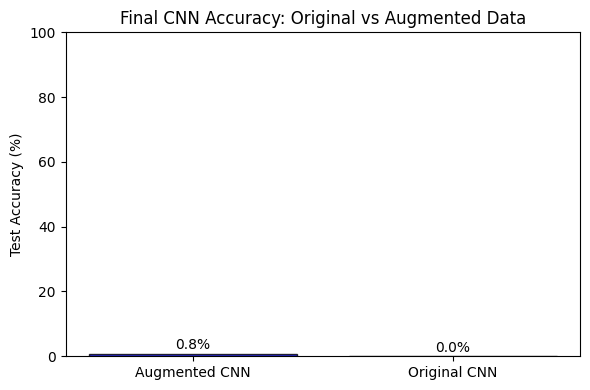

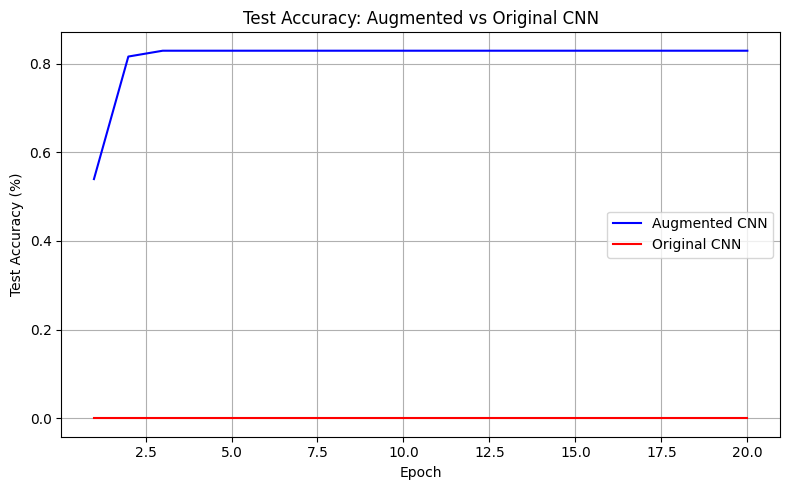

In [ ]:
final_acc_aug = aug_test_acc[-1]
final_acc_orig = orig_test_acc[-1]

print("\n" + "="*40)
print("CNN FINAL ACCURACY COMPARISON")
print("="*40)
print(f"{'Dataset':<12} {'Test Acc (%)':<10}")
print("-"*40)
print(f"Augmented    {final_acc_aug:<10.2f}")
print(f"Original     {final_acc_orig:<10.2f}")

plt.figure(figsize=(6, 4))
labels = ["Augmented CNN", "Original CNN"]
accs = [final_acc_aug, final_acc_orig]
colors = ["blue", "red"]
plt.bar(labels, accs, color=colors, edgecolor="black", alpha=0.8)
for i, v in enumerate(accs):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha='center', va='bottom', fontsize=10)
plt.ylabel("Test Accuracy (%)")
plt.title("Final CNN Accuracy: Original vs Augmented Data")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig("results/cnn_final_acc_bar.png", dpi=300, bbox_inches='tight')
plt.show()

epochs = range(1, 21)

plt.figure(figsize=(8, 5))
plt.plot(epochs, aug_test_acc, label="Augmented CNN", color="blue")
plt.plot(epochs, orig_test_acc, label="Original CNN", color="red")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")
plt.title("Test Accuracy: Augmented vs Original CNN")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("results/cnn_test_acc_epoch.png", dpi=300, bbox_inches='tight')
plt.show()